<a href="https://colab.research.google.com/github/Otza02/land2vec/blob/main/notebooks/prueba_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Otza02/land2vec.git
%cd /content/land2vec
!pip install -e .

Cloning into 'land2vec'...
remote: Enumerating objects: 329, done.
remote: Counting objects: 100% (329/329), done.
remote: Compressing objects: 100% (171/171), done.
remote: Total 329 (delta 160), reused 271 (delta 110), pack-reused 0 (from 0)
Receiving objects: 100% (329/329), 17.01 MiB | 18.38 MiB/s, done.
Resolving deltas: 100% (160/160), done.
/content/land2vec
Obtaining file:///content/land2vec
  Preparing metadata (setup.py) ... done
  Running setup.py develop for land2vec


### ---Restart session before next cell---

In [1]:
%cd /content/land2vec

/content/land2vec


In [2]:
from datetime import datetime
import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
import seaborn as sns
from collections import Counter
from copy import deepcopy

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import lr_scheduler

from land2vec.dataset import load_data, SequenceDatasetNonWindow
from land2vec.config import Config
from land2vec.model import GPTDecoder, run_epoch
from land2vec.tokenizer import Tokenizer
from land2vec.utils import (
    get_target_folder, load_config, load_model, load_train_results,
    save_config, save_model, save_train_results,
    compute_metrics, confusion_matrix, collect_predictions
    )

In [3]:
config = Config(patience=4, device="cuda" if torch.cuda.is_available() else "cpu", batch_size=1024, block_size=22)

torch.manual_seed(config.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.seed)
    torch.backends.cuda.enable_flash_sdp(True)
    torch.backends.cuda.enable_mem_efficient_sdp(True)
config.device

'cuda'

In [4]:
print("loading data")
file_path = "data/id_seqs_text_2000_2022_chaco_santiago_frontier.zip"
try:
    dataset = load_data(file_path="/content/land2vec/" + file_path)
except FileNotFoundError:
    dataset = load_data(file_path="../data/seqs_short.csv")

train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(config.seed)

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size], generator=generator)
loader_kwargs = dict(
    batch_size=config.batch_size,
    num_workers=config.num_workers,
    pin_memory=True,
    persistent_workers=config.device == "cuda",
)

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_kwargs,
)

loading data


100%|██████████| 1424457/1424457 [00:20<00:00, 70784.46it/s]


## Exploring

In [19]:
count = Counter(Tokenizer.VOCAB.keys())
for seq in train_dataset.dataset.encoded:
    count.update(Tokenizer.decode(seq).split("-"))
count

Counter({'[UNK]': 1,
         'A': 9961737,
         'F': 16188696,
         'G': 133703,
         'Wt': 466315,
         'U': 21095,
         'Sh': 5920939,
         'Sp': 13238,
         'B': 1,
         'Wa': 56796,
         'Nd': 1})

In [20]:
weights = torch.zeros(
    len(Tokenizer.VOCAB),
    dtype=torch.float32,
)

for token, freq in count.items():
    idx = Tokenizer.VOCAB[token]
    if token == "[UNK]":
        weights[idx] = 0.0
    else:
        weights[idx] = 1 / np.sqrt(freq)

# normalizar solo clases válidas
valid = weights > 0
weights[valid] /= weights[valid].mean()
weights = weights.to(config.device)
weights

tensor([0.0000e+00, 1.5647e-03, 1.2274e-03, 1.3506e-02, 7.2318e-03, 3.4001e-02,
        2.0295e-03, 4.2922e-02, 4.9384e+00, 2.0722e-02, 4.9384e+00],
       device='cuda:0')

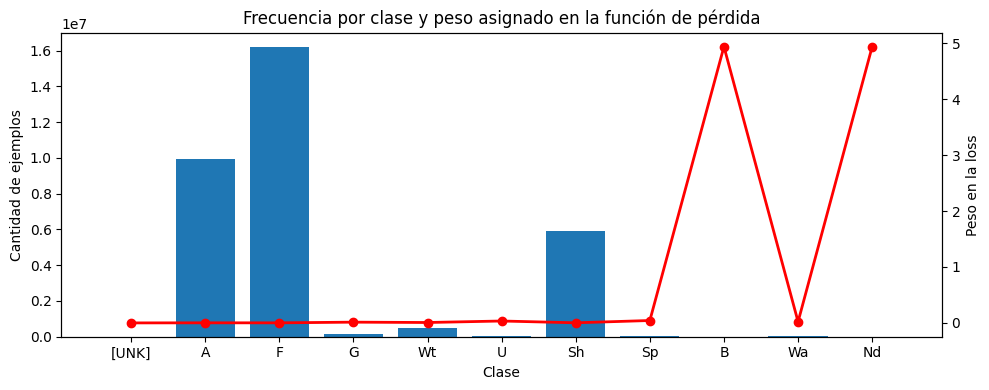

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar(count.keys(), count.values(), label="frequency")
ax2.plot(count.keys(), weights.cpu().numpy(), color="red", marker="o", linewidth=2, label="Peso en la loss")

ax1.set_xlabel("Clase")
ax1.set_ylabel("Frecuencia")
ax2.set_ylabel("Peso")
ax1.set_title("Frecuencia por clase y peso asignado")
plt.tight_layout()
plt.show()

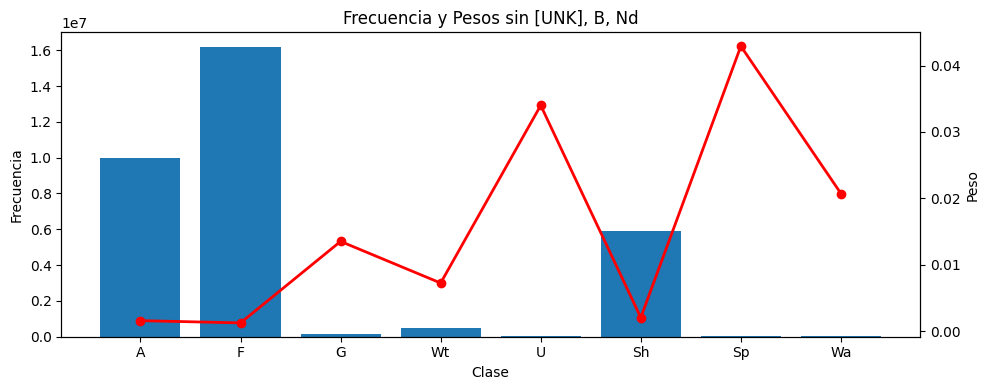

In [35]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.bar([k for k, v in count.items() if v > 10], [v for k, v in count.items() if v > 10], label="frequency")
ax2.plot([k for k, v in count.items() if v > 10], [w for w, v in zip(weights.cpu().numpy(), count.values()) if v > 10], color="red", marker="o", linewidth=2, label="Peso en la loss")

ax1.set_xlabel("Clase")
ax1.set_ylabel("Frecuencia")
ax2.set_ylabel("Peso")
ax1.set_title("Frecuencia y Pesos sin [UNK], B, Nd")
plt.tight_layout()
plt.show()

In [ ]:
config

Config(block_size=22, n_embd=128, n_head=4, n_layer=4, dropout=0.1, epochs=25, lr=0.001, patience=4, min_lr=1e-06, weight_decay=0.01, num_workers=2, batch_size=1024, device='cuda', seed=42)

In [ ]:
model = GPTDecoder(
    vocab_size=len(Tokenizer.VOCAB),
    block_size=config.block_size,
    n_embd=config.n_embd,
    n_head=config.n_head,
    n_layer=config.n_layer,
    dropout=config.dropout,
).to(config.device)

optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay, fused=config.device == "cuda")
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs, eta_min=config.min_lr)
scaler = torch.amp.GradScaler(enabled=True) if config.device == "cuda" else None

print(f"Weights: {weights}")
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")

Weights: tensor([0.0000e+00, 1.5647e-03, 1.2274e-03, 1.3506e-02, 7.2318e-03, 3.4001e-02,
        2.0295e-03, 4.2922e-02, 4.9384e+00, 2.0722e-02, 4.9384e+00],
       device='cuda:0')
parameters: 795,520


In [ ]:
best_model_state = None
best_val_macro_f1 = -float("inf")
best_epoch = 0
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "val_ppl": [],
    "val_macro_f1": [],
    "accuracy": [],
    "lr": [],
    "epoch_time": [],
    "tokens_per_sec": [],
}

global_start = datetime.now()
for epoch in range(config.epochs):
    start = datetime.now()
    train_loss = run_epoch(model, train_loader, weights, optimizer, config.device, scaler, use_amp=True)
    # val_loss = run_epoch(model, val_loader, None, weights, config.device, None, use_amp=True)

    val_preds, val_true, val_loss = collect_predictions(model, val_loader, config.device, weights)
    metrics = compute_metrics(val_true, val_preds)

    if metrics["macro_f1"] > best_val_macro_f1:
        best_val_macro_f1 = metrics["macro_f1"]
        best_epoch = epoch + 1
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    epoch_seconds = (datetime.now() - start).seconds
    if epoch_seconds < 1:
        epoch_seconds = 1

    tokens_processed = (len(train_loader.dataset) * config.block_size)
    tokens_per_sec = (tokens_processed / epoch_seconds)


    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_ppl"].append(torch.math.exp(val_loss))
    history["val_macro_f1"].append(metrics["macro_f1"])
    history["accuracy"].append(metrics["accuracy"])
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_seconds)
    history["tokens_per_sec"].append(tokens_per_sec)

    ppl = torch.math.exp(val_loss)
    print(
        f"[Epoch {epoch+1:03d}] | "
        f"train={train_loss:.4f} | "
        f"val={val_loss:.4f} | "
        f"ppl={ppl:.4f} | "
        f"lr={current_lr:.2e} | "
        f"time={(epoch_seconds // 60):02}:{(epoch_seconds % 60):02} | "
        f"token/s={tokens_per_sec:,.0f} | "
    )

    if patience_counter >= config.patience:
        print("Early stopping...")
        model.load_state_dict(best_model_state)
        break

total_time = (datetime.now() - global_start).seconds
print("=== Finished Training ===")
print(f"best epoch: {best_epoch}")
print(f"best val macro f1: {best_val_macro_f1:.4f}")
print(f"total training time: {total_time // 60:02}:{total_time % 60:02}")

[Epoch 001] | train=0.0874 | val=0.0427 | ppl=1.0436 | lr=9.96e-04 | time=00:38 | token/s=659,748 | 
[Epoch 002] | train=0.0620 | val=0.0429 | ppl=1.0439 | lr=9.84e-04 | time=00:35 | token/s=716,298 | 
[Epoch 003] | train=0.0616 | val=0.0428 | ppl=1.0437 | lr=9.65e-04 | time=00:35 | token/s=716,298 | 
[Epoch 004] | train=0.0612 | val=0.0430 | ppl=1.0439 | lr=9.38e-04 | time=00:37 | token/s=677,579 | 
[Epoch 005] | train=0.0611 | val=0.0427 | ppl=1.0436 | lr=9.05e-04 | time=00:36 | token/s=696,401 | 
Early stopping...
=== Finished Training ===
best epoch: 1
best val macro f1: 0.9886
total training time: 03:03


In [ ]:
target_folder = get_target_folder("balanced_1")
target_folder

PosixPath('../models/balanced_1')

In [ ]:
os.makedirs(str(target_folder), exist_ok=True)
save_config(config, target_folder)
save_model(model, target_folder)
save_train_results(history, target_folder)

Config saved to ../models/balanced_1/config.json
Model saved to ../models/balanced_1/model.pt
Train data saved to ../models/balanced_1/train_data.csv


In [ ]:
train_results = pd.DataFrame(history)

## Train evaluation

In [11]:
from pathlib import Path
target_folder = Path(os.path.join(os.getcwd(), "models", "balanced_1"))
target_folder

PosixPath('/content/land2vec/models/balanced_1')

In [12]:
config = load_config(target_folder)
model = load_model(config, target_folder)
train_results = load_train_results(target_folder)

In [13]:
train_results.head()

,train_loss,val_loss,val_ppl,val_macro_f1,accuracy,lr,epoch_time,tokens_per_sec
0,0.087402,0.042713,1.043639,0.988641,0.991696,0.000996,38,659748.157895
1,0.062042,0.042934,1.043869,0.988641,0.991696,0.000984,35,716298.000000
2,0.061615,0.042818,1.043748,0.988641,0.991696,0.000965,35,716298.000000
3,0.061218,0.042984,1.043921,0.988641,0.991696,0.000938,37,677579.189189
4,0.061096,0.042660,1.043583,0.988641,0.991696,0.000905,36,696400.833333


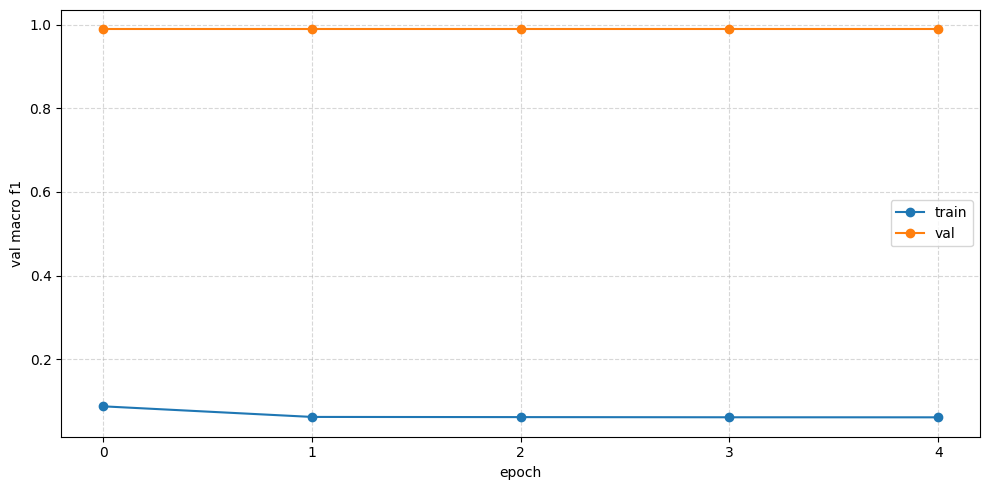

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_results["train_loss"], label="train", marker="o")
ax.plot(train_results["val_macro_f1"], label="val", marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("val macro f1")
ax.set_xticks(range(len(train_results["val_macro_f1"])))
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend()
plt.show()

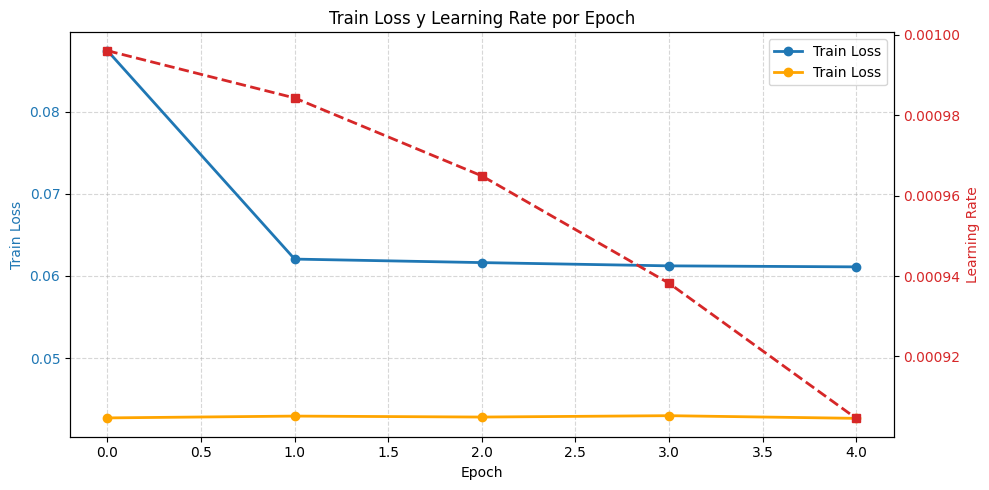

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# ----- Eje Y izquierdo (train loss) -----
color1 = 'tab:blue'

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color1)

ax1.plot(train_results["train_loss"],color=color1 ,marker='o', linewidth=2, label='Train Loss')
ax1.plot(train_results["val_loss"],color="orange" ,marker='o', linewidth=2, label='Train Loss')

ax1.tick_params(axis='y', labelcolor=color1)
ax1.legend(loc='upper right')

# ----- Eje Y derecho (learning rate) -----
ax2 = ax1.twinx()

color2 = 'tab:red'

ax2.set_ylabel('Learning Rate', color=color2)
ax2.plot(train_results["lr"], color=color2, marker='s', linestyle='--', linewidth=2, label='Learning Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Train Loss y Learning Rate por Epoch')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

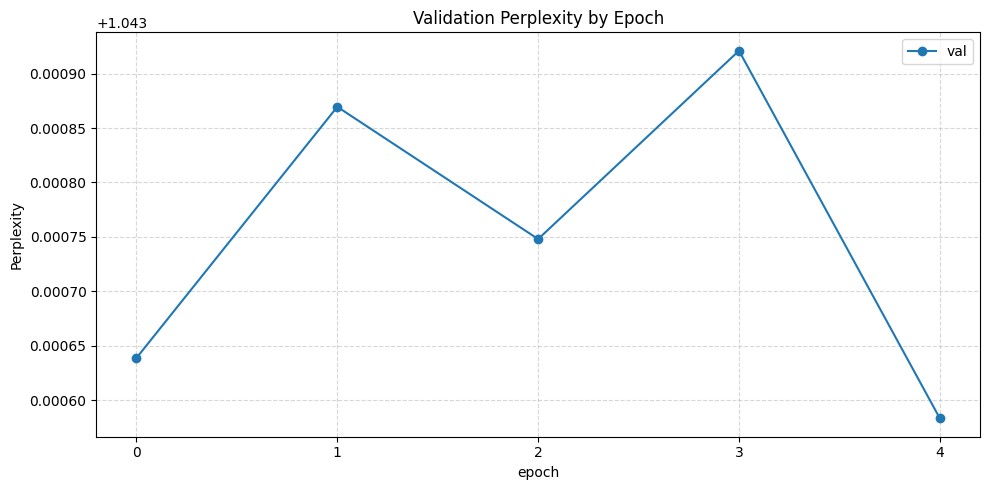

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_results["val_ppl"], label="val", marker="o")
# ax.set_ylim(1.03, 1.04)
ax.set_xlabel("epoch")
ax.set_ylabel("Perplexity")
ax.set_xticks(range(len(train_results["val_ppl"])))
ax.grid(True, linestyle='--', alpha=0.5)
plt.title("Validation Perplexity by Epoch")
plt.tight_layout()
plt.legend()
plt.show()

## Predicción



In [ ]:
@torch.no_grad()
def predict_next(model, idx):
    model.eval()
    logits = model(idx)
    logits = logits[:, -1, :]
    probs = torch.softmax(logits, dim=-1)
    pred = logits.argmax(dim=-1)
    return pred, probs

@torch.no_grad()
def next_token_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return correct / total

In [ ]:
next_token_accuracy(model, test_loader, config.device)

0.9916412292418807

In [ ]:
@torch.no_grad()
def accuracy_by_position(model, loader, device):
    model.eval()
    acc_sum = None
    batches = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=-1)
        correct = (preds == y).float()
        pos_acc = correct.mean(dim=0)
        if acc_sum is None:
            acc_sum = pos_acc
        else:
            acc_sum += pos_acc
        batches += 1
    return (acc_sum / batches).cpu()

In [ ]:
pos_acc = accuracy_by_position(model, test_loader, config.device)

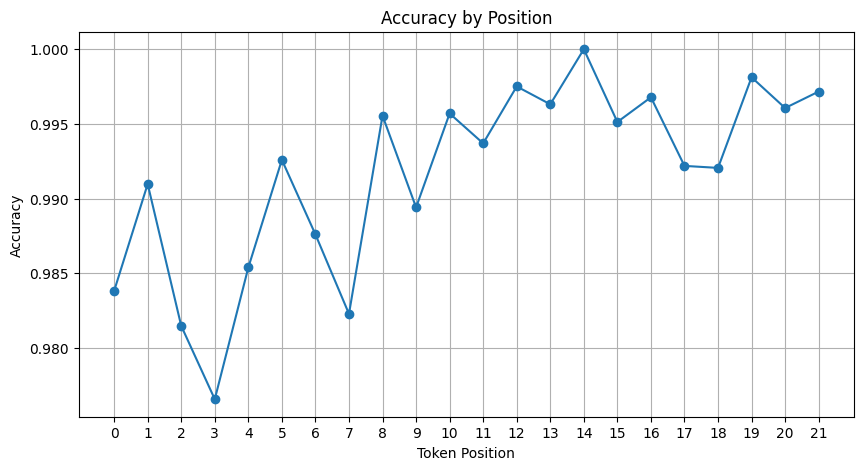

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(pos_acc, marker="o")
ax.set_xticks(range(config.block_size))
ax.set_xlabel("Token Position")
ax.set_ylabel("Accuracy")
plt.title("Accuracy by Position")
plt.grid(True)
plt.show()

In [23]:
model.eval()
all_preds, all_targets, val_loss = collect_predictions(model, test_loader, config.device, weights)
metrics = compute_metrics(all_targets, all_preds)

In [24]:
print(f"Accuracy: {metrics["accuracy"]:.4f}")
print(f"Macro f1: {metrics["macro_f1"]:.4f}")

Accuracy: 0.9916
Macro f1: 0.9886


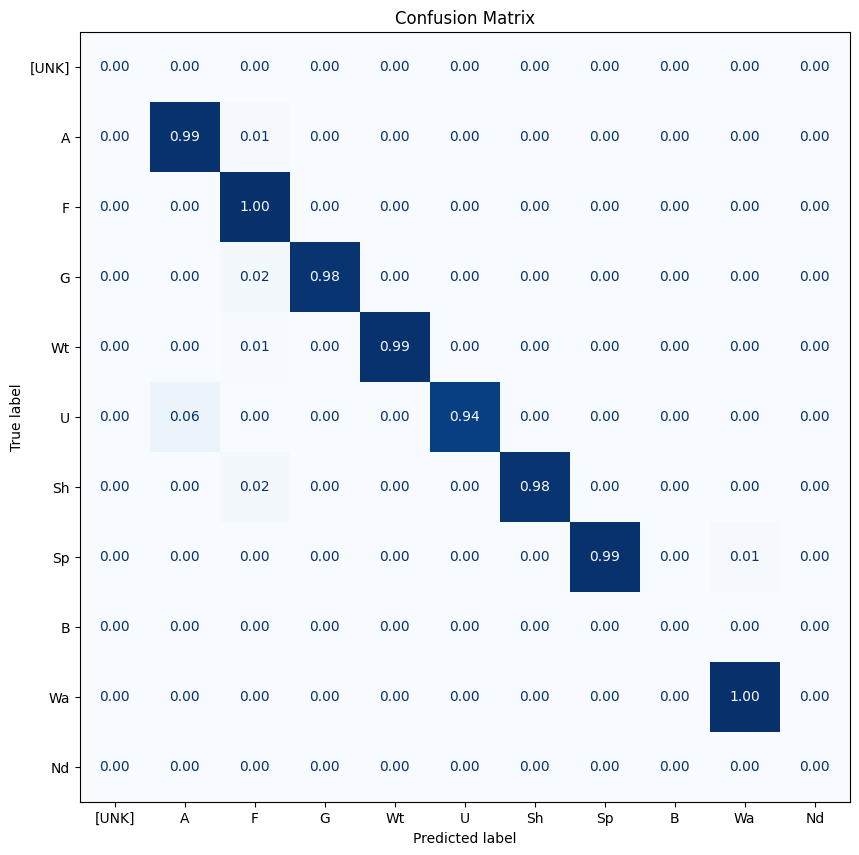

In [33]:
valid_ids = sorted(Tokenizer.REVERSE_VOCAB.keys())

cm = confusion_matrix(all_targets, all_preds, labels=valid_ids, normalize="true")

labels = [Tokenizer.REVERSE_VOCAB[i] for i in valid_ids]

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
ax.grid(False)
disp.ax_.set_title("Confusion Matrix")
plt.show()

In [34]:
train_results["val_macro_f1"]

,val_macro_f1
0,0.988641
1,0.988641
2,0.988641
3,0.988641
4,0.988641
